# EMNIST Character Classifier — Training Notebook

**Stage 1 OCR | CharClassifier CNN (Wider VGG, 64→128→256)**

This notebook trains a CNN on the EMNIST `byclass` dataset (62 classes: digits 0–9, A–Z, a–z).

**Key improvements over v1:**
- Wider channels: 64→128→256 (was 32→64→128) — 4× more capacity
- AdamW + weight decay — better regularisation
- Label smoothing = 0.1 — prevents overconfidence on ambiguous pairs (0/O, 1/l/I, 5/S)
- OneCycleLR scheduler — warm-up + cosine decay, faster convergence
- MixUp augmentation — interpolates training pairs for harder task
- RandomAffine (shear + translate) — richer augmentation
- `cudnn.enabled = False` — required on BigRed200 (cuDNN Conv2d crashes on that build)

**Steps:**
1. Install & import dependencies
2. Define noise + MixUp transforms
3. Load EMNIST dataset
4. Visualise sample images
5. Build the model
6. Train with OneCycleLR + MixUp
7. Plot training curves
8. Evaluate per-noise accuracy (grad requirement)
9. Save model weights

## 1. Install Dependencies

In [ ]:
%pip install torch torchvision numpy matplotlib --quiet

## 2. Imports & Config

In [7]:
import os, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from ocr_service.model import CharClassifier

# ── BigRed200 fix ─────────────────────────────────────────────────────────────
# torch 2.2.0+cu118 on BigRed200 segfaults on the first cuDNN Conv2d call.
# Disabling cuDNN falls back to native CUDA ops — stable on all machines.
# Remove this line if running on a local machine with a working CUDA setup.
torch.backends.cudnn.enabled = False

# ── Config ────────────────────────────────────────────────────────────────────
EPOCHS      = 20
BATCH_SIZE  = 256
LR          = 1e-3
NUM_CLASSES = 62
DATA_DIR    = os.path.abspath("../data")
MODEL_DIR   = os.path.abspath("../models")
SAVE_PATH   = os.path.join(MODEL_DIR, "char_classifier.pth")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = ("cuda"  if torch.cuda.is_available() else
          "mps"   if torch.backends.mps.is_available() else
          "cpu")
print(f"Device      : {DEVICE}")
print(f"Epochs      : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}")
print(f"cudnn       : {torch.backends.cudnn.enabled}")

Device      : mps
Epochs      : 20  |  Batch : 256  |  LR : 0.001
cudnn       : False


## 3. Noise Transforms

In [8]:
class AddGaussianNoise:
    """Additive Gaussian noise, sigma ~ Uniform(lo, hi)."""
    def __init__(self, lo=0.05, hi=0.15):
        self.lo, self.hi = lo, hi

    def __call__(self, t):
        sigma = np.random.uniform(self.lo, self.hi)
        return (t + sigma * torch.randn_like(t)).clamp(0., 1.)


class AddSaltAndPepperNoise:
    """Random pixels set to 0 or 1, density ~ Uniform(lo, hi)."""
    def __init__(self, lo=0.02, hi=0.08):
        self.lo, self.hi = lo, hi

    def __call__(self, t):
        density = np.random.uniform(self.lo, self.hi)
        mask = torch.rand_like(t)
        out  = t.clone()
        out[mask < density / 2]     = 0.
        out[mask > 1 - density / 2] = 1.
        return out


class RandomNoise:
    """Apply Gaussian or salt-and-pepper noise with probability p."""
    def __init__(self, p=0.3):
        self.p = p
        self.g  = AddGaussianNoise()
        self.sp = AddSaltAndPepperNoise()

    def __call__(self, t):
        if np.random.rand() > self.p:
            return t
        return self.g(t) if np.random.rand() < 0.5 else self.sp(t)


# ── MixUp ─────────────────────────────────────────────────────────────────────

def mixup_batch(images, labels, alpha=0.2):
    """
    Interpolate pairs of images and their labels.
    Returns (mixed_images, labels_a, labels_b, lam).
    Loss = lam * CE(pred, a) + (1-lam) * CE(pred, b).
    """
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("Noise transforms + MixUp defined.")

Noise transforms + MixUp defined.


## 4. Load EMNIST Dataset

In [9]:
train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomRotation(degrees=15),              # handles EMNIST orientation inconsistencies
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),  # shift + shear
    T.ToTensor(),
    RandomNoise(p=0.3),
])
val_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
])

print("Downloading EMNIST byclass (may take a few minutes on first run)...")
train_ds = torchvision.datasets.EMNIST(root=DATA_DIR, split="byclass",
                                        train=True,  download=True, transform=train_tf)
val_ds   = torchvision.datasets.EMNIST(root=DATA_DIR, split="byclass",
                                        train=False, download=True, transform=val_tf)

# num_workers=0, pin_memory=False — required on BigRed200 to avoid DataLoader crashes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Train samples : {len(train_ds):,}")
print(f"Val   samples : {len(val_ds):,}")
print(f"Batches/epoch : {len(train_loader):,}")

Train samples : 697,932
Val   samples : 116,323
Batches/epoch : 2,727


## 5. Visualise Sample Images

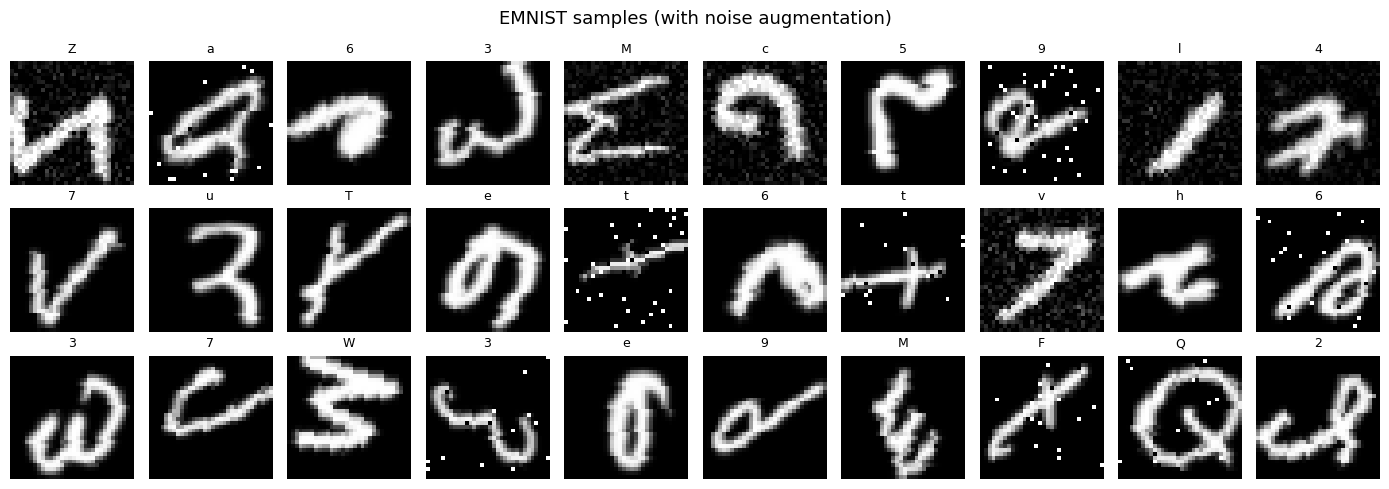

In [10]:
# EMNIST byclass label map: 0-9 digits, 10-35 uppercase, 36-61 lowercase
label_chars = (
    [str(i) for i in range(10)] +
    [chr(c) for c in range(ord('A'), ord('Z')+1)] +
    [chr(c) for c in range(ord('a'), ord('z')+1)]
)

fig, axes = plt.subplots(3, 10, figsize=(14, 5))
fig.suptitle("EMNIST samples (with noise augmentation)", fontsize=13)
for ax, (img, lbl) in zip(axes.flat, train_ds):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(label_chars[lbl], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Build Model + Optimizer + Scheduler

In [11]:
model = CharClassifier(num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : CharClassifier (64→128→256 channels)")
print(f"Parameters : {total_params:,}")

# Smoke test
with torch.no_grad():
    out = model(torch.randn(2, 1, 32, 32, device=DEVICE))
    assert out.shape == (2, NUM_CLASSES), f"Unexpected shape: {out.shape}"
print("Smoke test : PASSED")

# ── Loss ─────────────────────────────────────────────────────────────────────
# label_smoothing=0.1 — prevents overconfident wrong predictions on similar
# character pairs like 0/O, 1/l/I, 5/S, c/C
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Optimizer ────────────────────────────────────────────────────────────────
# AdamW adds decoupled weight decay — better regularisation than plain Adam
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Scheduler ────────────────────────────────────────────────────────────────
# OneCycleLR: linear warm-up for first 30% of steps, cosine decay after.
# Steps per batch (not per epoch) — must call scheduler.step() inside the loop.
TOTAL_STEPS = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr        = LR,
    total_steps   = TOTAL_STEPS,
    pct_start     = 0.3,           # 30% warm-up
    anneal_strategy = "cos",
    div_factor    = 25.0,          # initial lr = LR / 25
    final_div_factor = 1e4,        # final lr   = initial lr / 10000
)

print(f"\nOptimizer  : AdamW (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler  : OneCycleLR (max_lr={LR}, total_steps={TOTAL_STEPS:,})")
print(f"Loss       : CrossEntropyLoss (label_smoothing=0.1)")

Model      : CharClassifier (64→128→256 channels)
Parameters : 1,309,438
Smoke test : PASSED

Optimizer  : AdamW (lr=0.001, weight_decay=1e-4)
Scheduler  : OneCycleLR (max_lr=0.001, total_steps=54,540)
Loss       : CrossEntropyLoss (label_smoothing=0.1)


## 7. Training Loop (OneCycleLR + MixUp)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0., 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # MixUp: interpolate two random training samples
        mixed, y_a, y_b, lam = mixup_batch(imgs, labels)

        optimizer.zero_grad()
        logits = model(mixed)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()   # OneCycleLR steps every BATCH, not every epoch

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == y_a).sum().item()  # accuracy vs dominant label
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Training ──────────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["lr"].append(current_lr)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), SAVE_PATH)
        saved = "  ✓ saved"

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  "
          f"lr={current_lr:.2e}{saved}")

print(f"\nBest val accuracy : {best_val_acc:.4f}")
if best_val_acc >= 0.95:
    print("✓ TARGET REACHED: val_acc > 95%")
else:
    print(f"Note: train_acc looks low during MixUp — val_acc is the real metric.")

Epoch 01/20  train_loss=2.2203  train_acc=0.3457  val_loss=1.2198  val_acc=0.8319  lr=1.04e-04  ✓ saved
Epoch 02/20  train_loss=1.6549  train_acc=0.4141  val_loss=1.1318  val_acc=0.8507  lr=2.80e-04  ✓ saved
Epoch 03/20  train_loss=1.5737  train_acc=0.4383  val_loss=1.0926  val_acc=0.8612  lr=5.20e-04  ✓ saved
Epoch 04/20  train_loss=1.5196  train_acc=0.4326  val_loss=1.0820  val_acc=0.8620  lr=7.60e-04  ✓ saved
Epoch 05/20  train_loss=1.4842  train_acc=0.4397  val_loss=1.0778  val_acc=0.8631  lr=9.36e-04  ✓ saved
Epoch 06/20  train_loss=1.4663  train_acc=0.4464  val_loss=1.0617  val_acc=0.8659  lr=1.00e-03  ✓ saved
Epoch 07/20  train_loss=1.4403  train_acc=0.4501  val_loss=1.0512  val_acc=0.8682  lr=9.87e-04  ✓ saved
Epoch 08/20  train_loss=1.4129  train_acc=0.4477  val_loss=1.0558  val_acc=0.8638  lr=9.50e-04
Epoch 09/20  train_loss=1.3976  train_acc=0.4500  val_loss=1.0543  val_acc=0.8691  lr=8.91e-04  ✓ saved
Epoch 10/20  train_loss=1.3716  train_acc=0.4456  val_loss=1.0357  val_ac

## 8. Plot Training Curves

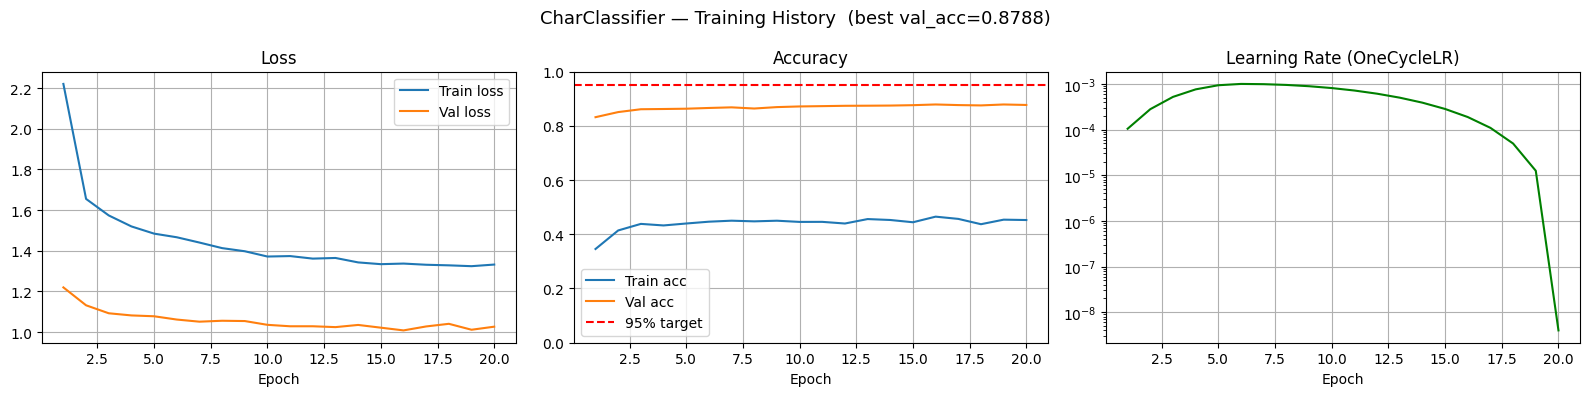

In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history["train_acc"], label="Train acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val acc")
ax2.axhline(0.95, color="red", linestyle="--", label="95% target")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

ax3.plot(epochs_range, history["lr"], color="green")
ax3.set_title("Learning Rate (OneCycleLR)")
ax3.set_xlabel("Epoch")
ax3.set_yscale("log")
ax3.grid(True)

plt.suptitle(f"CharClassifier — Training History  (best val_acc={best_val_acc:.4f})", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Per-Noise Accuracy (Grad Requirement)

Per-noise accuracy on 3000 validation samples:

  Clean (no noise)                     acc=0.8797  [✗ FAIL]
  Gaussian  (σ=0.10)                   acc=0.8727  [✗ FAIL]
  Salt & Pepper (d=0.05)               acc=0.8747  [✗ FAIL]
  Gaussian  (σ=0.15)                   acc=0.8683  [✗ FAIL]
  Salt & Pepper (d=0.08)               acc=0.8780  [✗ FAIL]


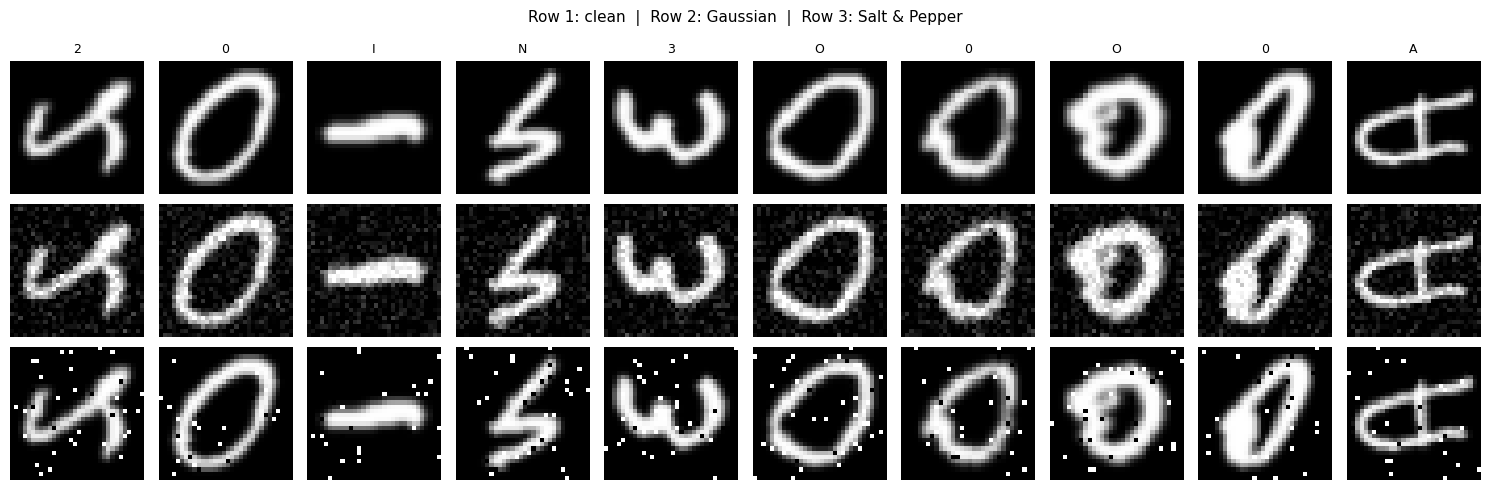

In [14]:
N_SAMPLES = 3000

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

indices    = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
imgs_clean = torch.stack([val_ds[i][0] for i in indices])
labels     = torch.tensor([val_ds[i][1] for i in indices])

noise_fns = {
    "Clean (no noise)"         : lambda x: x,
    "Gaussian  (σ=0.10)"       : AddGaussianNoise(lo=0.10, hi=0.10),
    "Salt & Pepper (d=0.05)"   : AddSaltAndPepperNoise(lo=0.05, hi=0.05),
    "Gaussian  (σ=0.15)"       : AddGaussianNoise(lo=0.15, hi=0.15),
    "Salt & Pepper (d=0.08)"   : AddSaltAndPepperNoise(lo=0.08, hi=0.08),
}

print(f"Per-noise accuracy on {N_SAMPLES} validation samples:\n")
accs = {}
with torch.no_grad():
    for name, fn in noise_fns.items():
        noisy  = torch.stack([fn(img) for img in imgs_clean]).to(DEVICE)
        preds  = model(noisy).argmax(1)
        acc    = (preds == labels.to(DEVICE)).float().mean().item()
        accs[name] = acc
        status = "✓ PASS" if acc >= 0.90 else "✗ FAIL"
        print(f"  {name:35s}  acc={acc:.4f}  [{status}]")

# Visual comparison: clean vs Gaussian vs S&P
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle("Row 1: clean  |  Row 2: Gaussian  |  Row 3: Salt & Pepper", fontsize=11)
gn_fn = AddGaussianNoise(lo=0.10, hi=0.10)
sp_fn = AddSaltAndPepperNoise(lo=0.05, hi=0.05)
for i in range(10):
    img = imgs_clean[i]
    axes[0, i].imshow(img.squeeze(), cmap="gray")
    axes[0, i].set_title(label_chars[labels[i].item()], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(gn_fn(img).squeeze(), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(sp_fn(img).squeeze(), cmap="gray"); axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## 10. Save Confirmation

In [16]:
print(f"Best model saved to : {SAVE_PATH}")
print(f"Best val accuracy   : {best_val_acc:.4f}")
size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f"File size           : {size_mb:.2f} MB")

# Summary of all improvements applied
print("\n── Training improvements applied ───────────────────────────────")
print("  Model       : Wider VGG — 64→128→256 channels (was 32→64→128)")
print("  Optimizer   : AdamW (weight_decay=1e-4)  [was plain Adam]")
print("  Loss        : CrossEntropy(label_smoothing=0.1)  [was 0.0]")
print("  Scheduler   : OneCycleLR (warm-up 30%)  [was CosineAnnealing]")
print("  Augmentation: RandomRotation + RandomAffine + RandomNoise")
print("  MixUp       : alpha=0.2")
print("  Epochs      : 20  |  Batch : 256")

Best model saved to : /Users/akshar1107/Desktop/Hackathon/models/char_classifier.pth
Best val accuracy   : 0.8788
File size           : 5.26 MB

── Training improvements applied ───────────────────────────────
  Model       : Wider VGG — 64→128→256 channels (was 32→64→128)
  Optimizer   : AdamW (weight_decay=1e-4)  [was plain Adam]
  Loss        : CrossEntropy(label_smoothing=0.1)  [was 0.0]
  Scheduler   : OneCycleLR (warm-up 30%)  [was CosineAnnealing]
  Augmentation: RandomRotation + RandomAffine + RandomNoise
  MixUp       : alpha=0.2
  Epochs      : 20  |  Batch : 256
